<a href="https://colab.research.google.com/github/benfsheedy/exoplanet-analysis/blob/main/exoplanet_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exoplanet Discovery Trends

This analysis reviews trends and data related to exoplanet discovery over the last 20 years.

Since 2006, there have been a number of major innovations in exoplanet detection, including the launch of Kepler (which observed a single patch of sky), TESS (which surveys the entire sky), and the JWST (which analyzes exoplanet data after discovery).

## Data Source

The data is sourced from the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu), accessed through its API and loaded into a Pandas dataframe.

## Key Findings

- **Exoplanet discovery is dominated by space missions and their data releases.** Kepler's batch analysis releases in 2014 and 2016 confirmed nearly 2,250 planets in two years. Since 2018, TESS has taken over as the primary discovery engine.

- **Exoplanet distance was trending upwards until around 2022.** Kepler's deep survey of distant stars pushed the mean discovery distance from under 1,000 light-years to over 3,000 by 2022. TESS, designed to study nearby bright stars for atmospheric follow-up, has begun pulling that average back down.

- **What we discover depends heavily on how we look.** Pre-Kepler radial velocity surveys found mostly large gas giants. The transit method used by Kepler and TESS revealed that small rocky planets (1–2 Earth radii) are actually the most common type in the galaxy.


*Each finding is explored in detail in the sections below.*

## Data Preparation

The columns best suited for this analysis are:

- `disc_year` — year the planet was confirmed, as an integer
- `pl_name` — planet name, used for counting unique discoveries
- `discoverymethod` — how the planet was detected
- `disc_facility` — the telescope, observatory, or mission that made the discovery
- `sy_dist` — distance from Earth to the planet's host star, in parsecs
- `pl_rade` — planet radius, in Earth radii (a proxy for planet size)
- `rowupdate` — used for deduplication

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MISSION_EVENTS = [
    (2009, 'Kepler launch'),
    (2018, 'TESS launch'),
    (2022, 'JWST operations'),
]

FACILITY_MAP = {
    'Kepler': 'Kepler',
    'K2': 'Kepler',
    'Transiting Exoplanet Survey Satellite (TESS)': 'TESS',
}

cols = "pl_name,disc_year,discoverymethod,disc_facility,sy_dist,pl_rade,rowupdate"
url = f"https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+{cols}+from+ps+where+disc_year+is+not+null&format=csv"
df = pd.read_csv(url, low_memory=False)
df['sy_dist'] = df['sy_dist'] * 3.26156  # parsecs to light-years

In [ ]:
print(f"Shape: {df.shape}")
print(f"\nNulls per column:\n{df.isnull().sum()}")
print(f"\nDuplicate planet names: {df.duplicated(subset='pl_name').sum()}")
print(f"\nYear range: {df['disc_year'].min()}–{df['disc_year'].max()}")
print(f"\nfacility counts:\n{df['disc_facility'].value_counts()}")

Shape: (39850, 7)

Nulls per column:
pl_name                0
disc_year              0
discoverymethod        0
disc_facility          0
sy_dist              854
pl_rade            12353
rowupdate              1
dtype: int64

Duplicate planet names: 33565

Year range: 1992–2026

facility counts:
disc_facility
Kepler                                                          28548
Transiting Exoplanet Survey Satellite (TESS)                     2282
K2                                                               2148
SuperWASP                                                        1029
La Silla Observatory                                              704
                                                                ...  
Winer Observatory                                                   1
Wide-field Infrared Survey Explorer (WISE) Satellite Mission        1
Very Long Baseline Array                                            1
South African Radio Astronomy Observatory (SARAO)          

In [ ]:
df.sample(10)

,pl_name,disc_year,discoverymethod,disc_facility,sy_dist,pl_rade,rowupdate
18306,Kepler-334 c,2014,Transit,Kepler,1391.348880,1.370,2014-11-18
15018,Kepler-924 b,2016,Transit,Kepler,3434.553142,NaN,2018-09-25
26404,Kepler-354 d,2014,Transit,Kepler,1807.112980,1.450,2016-05-06
35033,Kepler-603 b,2016,Transit,Kepler,5021.595623,2.350,2015-08-25
1972,HD 11964 b,2005,Radial Velocity,W. M. Keck Observatory,109.382612,NaN,2019-01-28
18251,Kepler-1046 b,2016,Transit,Kepler,2353.326433,1.610,2014-11-21
25698,Kepler-1380 b,2016,Transit,Kepler,8033.026586,2.732,2018-09-04
38102,Kepler-230 b,2014,Transit,Kepler,2416.013616,3791.050,2015-08-25
34637,Kepler-365 c,2014,Transit,Kepler,3388.728224,NaN,2018-09-25
3886,WASP-41 b,2012,Transit,SuperWASP,532.844319,NaN,2022-10-18


A few observations from the initial inspection:

- The dataset has multiple rows per planet, which is expected — different studies measure the same planet over time. Deduplication will be needed before analysis.
- `sy_dist` and `pl_rade` have meaningful null counts, since not every confirmed planet has a measured distance or radius.
- The transit method dominates by a wide margin, reflecting Kepler and TESS's outsized role in modern exoplanet discovery.
- The year range spans from 1992 (the first confirmed exoplanet) to 2026.

### Deduplication

As seen above, the dataset contains multiple rows per planet — different studies measure the same planet over time, so columns like distance and radius can vary across entries.

To deduplicate, only the most recently updated row for each planet is kept.

In [ ]:
df = (df.sort_values('rowupdate', ascending=False)
      .drop_duplicates(subset='pl_name')
      .reset_index(drop=True))

print(f"Duplicates: {df.duplicated(subset='pl_name').sum()}")

Duplicates: 0


In [ ]:
print(f"Rows: {len(df)}")
print(f"Year range: {df['disc_year'].min()}–{df['disc_year'].max()}")
print("\nNull counts:")
print(df.isnull().sum())

Rows: 6285
Year range: 1992–2026

Null counts:
pl_name               0
disc_year             0
discoverymethod       0
disc_facility         0
sy_dist             136
pl_rade            2838
rowupdate             0
dtype: int64


The categorical fields are clean, and the date range is accurate (the first confirmed exoplanet was discovered in 1992).

`sy_dist` and `pl_rade` have null counts, but as mentioned above this is expected. These nulls will be omitted from each respective analysis.

The vast majority of exoplanets in the dataset have been discovered since 2009, when Kepler began operations. The analysis below focuses on the 2006–present era to highlight the modern discovery landscape and the impact of major missions.

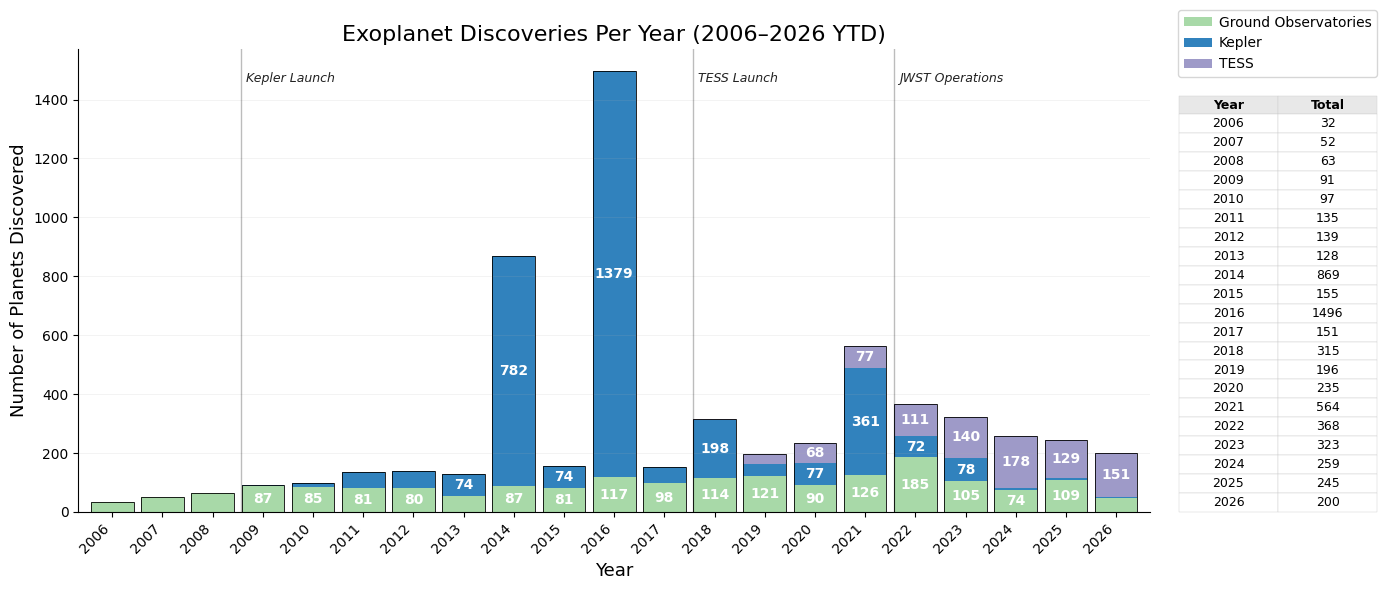

In [ ]:
# filter to post 2006 and group facilities
df_plot_filtered = df[df['disc_year'] >= 2006].copy()
df_plot_filtered['facility_group'] = (
    df_plot_filtered['disc_facility'].map(FACILITY_MAP).fillna('Ground Observatories')
)

# count by year and facility
facility_year = df_plot_filtered.groupby(['disc_year', 'facility_group'])['pl_name'].count().unstack(fill_value=0)
facility_year = facility_year[['Ground Observatories', 'Kepler', 'TESS']]

colors = ['#a8d9a8', '#3182bd', '#9e9ac8']  # green, dark blue, muted purple
fig, ax = plt.subplots(figsize=(14, 6))
facility_year.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.85)

# add data labels
label_threshold = 65
for bar in ax.patches:
    height = bar.get_height()
    if height >= label_threshold:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                int(height),
                ha='center', va='center',
                color='white', fontweight='bold')

totals = facility_year.sum(axis=1)
ax.bar(range(len(totals)), totals, width=0.85,
       facecolor='none', edgecolor='black', linewidth=0.6, zorder=5)

# add indication lines for mission launches
ypos = ax.get_ylim()[1] * 0.95
for year, label in MISSION_EVENTS:
    x = facility_year.index.get_loc(year) - 0.43
    ax.axvline(x=x, alpha=0.3, color='#222222', linestyle='-', linewidth=1)
    ax.text(x + 0.1, ypos, label, fontsize=9, va='top', color='#222222', fontstyle='italic')

# set axis and legend
ax.set_title('Exoplanet Discoveries Per Year (2006–2026 YTD)', fontsize=16)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Planets Discovered', fontsize=13)
ax.set_xticklabels(facility_year.index.astype(int), rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.1),
          borderpad=0.4, handletextpad=0.5)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, zorder=0)

# build the table data
table_data = [[int(year), int(total)] for year, total in zip(facility_year.index, facility_year.sum(axis=1))]

table = ax.table(
    cellText=table_data,
    colLabels=['Year', 'Total'],
    cellLoc='center',
    bbox=[1.027, 0.0, 0.185, 0.9]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# table formatting
for j in range(2):
    cell = table[(0, j)]
    cell.set_facecolor('#e8e8e8')
    cell.set_text_props(weight='bold')

for key, cell in table.get_celld().items():
    cell.set_linewidth(0.3)
    cell.set_edgecolor('#cccccc')

table.scale(1, 1.3)

sns.despine()
plt.tight_layout()
plt.show()

Something to note here are the spikes in 2014 and 2016. From 2009 to 2013, Kepler was primarily gathering data for later analysis. By 2014 and 2016, they were able to process and release a significant portion of the data collected, and hundreds of exoplanets were confirmed at once.

TESS launched in 2018 and has since replaced Kepler as the primary discovery mechanism for new exoplanets. In more recent years, particularly since JWST began operations, most discoveries are made by TESS. This is the intended relationship between the two missions: TESS discovers the planets, and JWST analyzes them.

## Planet Distance and Size

The next section examines planet size and distance from Earth over time.

### Mean Distance Over Time

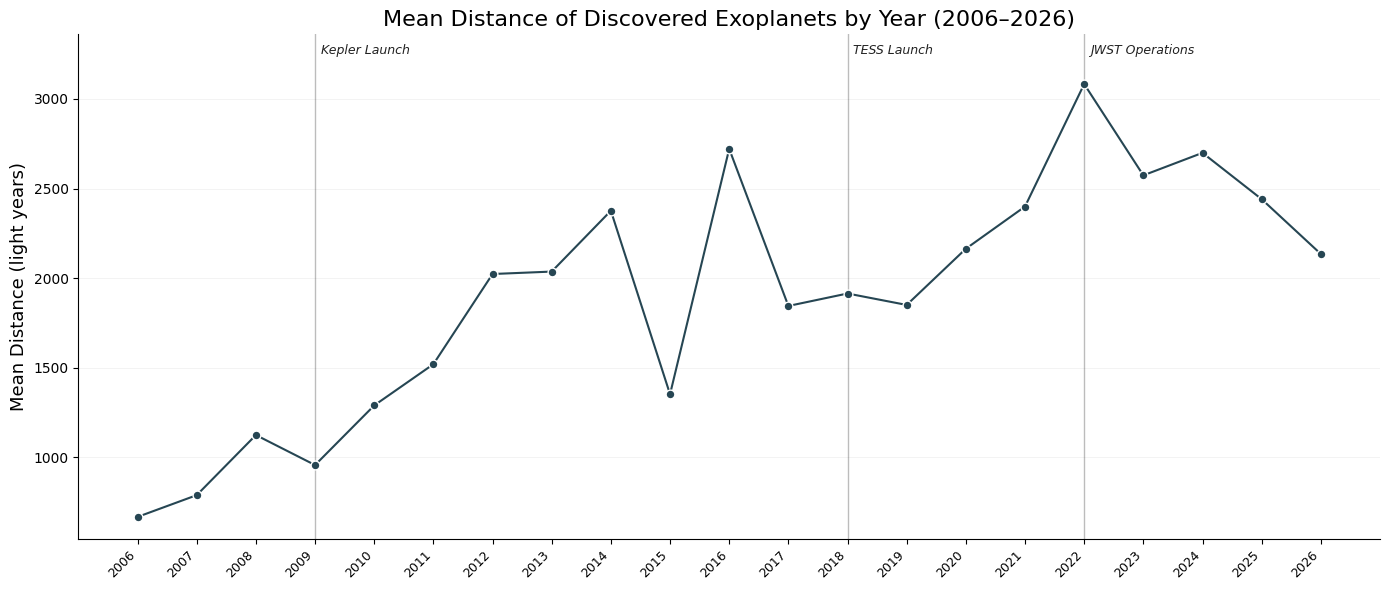

In [ ]:
# aggregate by year
df_year = (
    df.groupby('disc_year')
      .agg(mean_dist=('sy_dist', 'mean'), mean_rade=('pl_rade', 'mean'))
      .reset_index()
      .dropna(subset=['mean_dist'])
      .query('2006 <= disc_year <= 2026')
)

fig, ax = plt.subplots(figsize=(14, 6))

# plot line
ax.plot(df_year['disc_year'], df_year['mean_dist'],
        color='#264653', linewidth=1.5, zorder=2)
ax.scatter(df_year['disc_year'], df_year['mean_dist'],
           color='#264653', s=40, zorder=3,
           edgecolor='white', linewidth=1)

ymax = df_year['mean_dist'].max() * 1.09
ax.set_ylim(top=ymax)


# add indication lines for missions
for year, label in MISSION_EVENTS:
    ax.axvline(x=year, alpha=0.3, color='#222222', linewidth=1)
    ax.text(year + 0.1, 0.98, label, fontsize=9, fontstyle='italic', va='top',
            color='#222222', transform=ax.get_xaxis_transform())

ax.set_title('Mean Distance of Discovered Exoplanets by Year (2006–2026)', fontsize=16)
ax.set_ylabel('Mean Distance (light years)', fontsize=13)
ax.set_xticks(df_year['disc_year'])
ax.set_xticklabels(df_year['disc_year'].astype(int), rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=9)

ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

The trend shows that up through 2022, exoplanets being discovered were at greater distances over time. However, post 2022, it seems the trend has reversed slightly.

Before the Kepler era, discoveries were limited to just nearby stars, as most exoplanet discovery was attributed to ground-based telescopes. Once Kepler launched, it was exceptionally good at identifying distant exoplanets, leading to a strong positive trend through 2022. Post 2022, as Kepler was no longer active, its legacy findings were outpaced by new TESS findings, which by design targets closer exoplanets and stars.


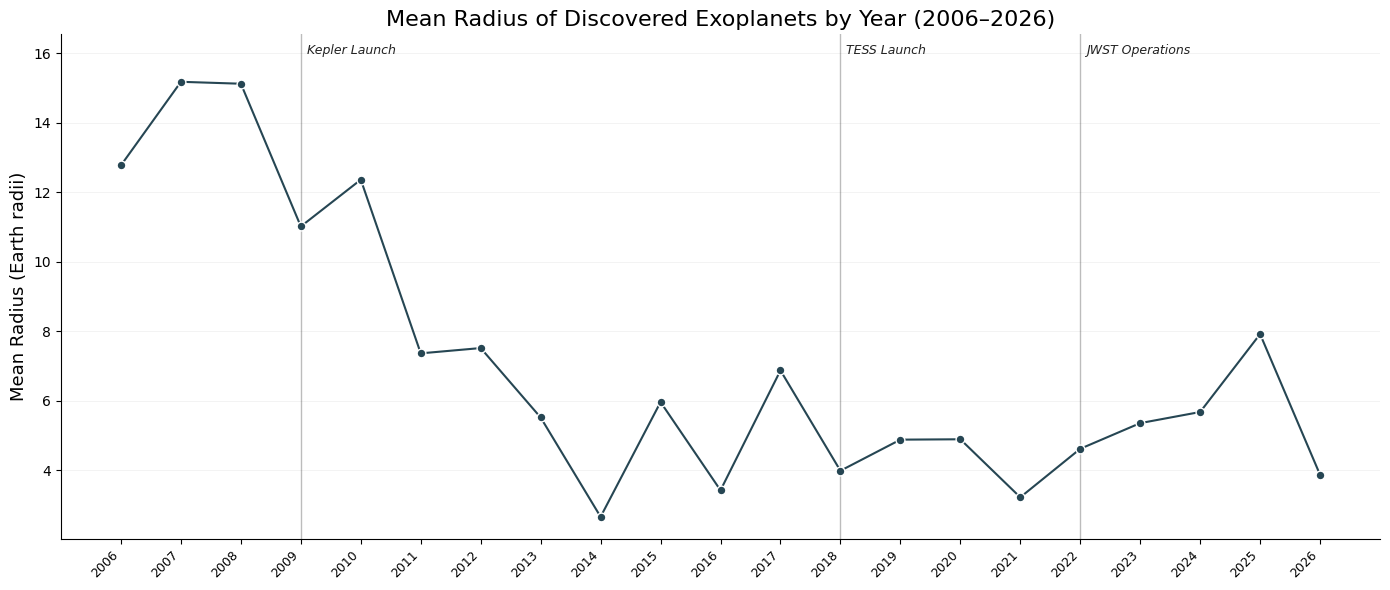

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# remove outlier Keplar-29 b
radius_year = (
    df[df['pl_rade'] < 30]
      .groupby('disc_year')['pl_rade'].mean()
      .reset_index()
      .query('2006 <= disc_year <= 2026')
)

# plot line
ax.plot(radius_year['disc_year'], radius_year['pl_rade'],
        color='#264653', linewidth=1.5, zorder=2)
ax.scatter(radius_year['disc_year'], radius_year['pl_rade'],
           color='#264653', s=40, zorder=3,
           edgecolor='white', linewidth=1)

ymax = radius_year['pl_rade'].max() * 1.09  # 9% extra room
ax.set_ylim(top=ymax)

# add indication lines for mission launches
for year, label in MISSION_EVENTS:
    ax.axvline(x=year, alpha=0.3, color='#222222', linewidth=1)
    ax.text(year + 0.1, 0.98, label, fontsize=9, fontstyle='italic', va='top',
            color='#222222', transform=ax.get_xaxis_transform())

ax.set_title('Mean Radius of Discovered Exoplanets by Year (2006–2026)', fontsize=16)
ax.set_ylabel('Mean Radius (Earth radii)', fontsize=13)
ax.set_xticks(radius_year['disc_year'])
ax.set_xticklabels(radius_year['disc_year'].astype(int), rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=9)

ax.grid(axis='y', alpha=0.2, linewidth=0.5, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

*Note: one planet (Kepler-29 b) was excluded from this chart due to an implausible radius value (2,327 Earth radii) in the catalog, likely a unit-conversion error.*


Before Kepler, most planets were discovered by ground-based observatories using radial velocity. That method is heavily biased toward large gas giants in tight orbits, and is less effective at identifying small rocky planets.

Kepler used the transit method instead, which is much better suited to detecting smaller planets. As Kepler's findings came in, the mean radius of newly discovered planets dropped sharply. Subsequent research has confirmed that small rocky planets (around 1-2 Earth radii) are actually the most common type of exoplanet in the galaxy, which was one of the most important revelations in the history of the field!
